In [1]:
import parametrization, mesh, mesh_utilities, numpy as np
target_surface = mesh_utilities.subdivide_loop(mesh.Mesh("../examples/squidward_remesh.obj"), 1)
rparam = parametrization.RegularizedParametrizerSVD(target_surface, np.loadtxt('results/squidward/param_laptop.txt'))

In [10]:
np.savetxt('results/squidward/param_laptop_resave.txt', rparam.uv())

In [2]:
import visualization, wall_width_formulas as wwf
nsubdiv=3
upsampledMesh, upsampledAngles, upsampledStretches = rparam.upsampledVertexLeftStretchAnglesAndMagnitudes(nsubdiv)
alphaMin = wwf.stretchFactorForCanonicalWallWidth(wwf.canonicalWallWidthForGeometry(3, 10))
alphaMax = wwf.stretchFactorForCanonicalWallWidth(wwf.canonicalWallWidthForGeometry(1, 10))
upsampledStretches = np.clip(upsampledStretches, alphaMin, alphaMax)

In [3]:
import wall_generation
(sdfVertices, sdfTris, sdf) = wall_generation.evaluate_stripe_field(upsampledMesh.vertices(), upsampledMesh.triangles(), upsampledAngles,
                                                                    wwf.canonicalWallWidthForStretchFactor(upsampledStretches), frequency=3.75)

In [4]:
import pickle
pickle.dump((sdfVertices, sdfTris, sdf), open('results/squidward/stripe_field_laptop.pkl', 'wb'))

In [12]:
import pickle
sdfVertices, sdfTris, sdf = pickle.load(open('results/squidward/stripe_field_laptop.pkl', 'rb'))

In [29]:
from sheet_meshing import generateSheetMesh
s, iwv, iwbv = generateSheetMesh(sdfVertices, sdfTris, sdf, triArea=0.05, permitWallInteriorVertices=False)

In [487]:
s.save('results/squidward/top_sheet_f3.75_remeshed_walls.msh')
np.savetxt('results/squidward/fuse_markers_f3.75_remeshed_walls.txt', iwv)

In [ ]:
from tri_mesh_viewer import TriMeshViewer
sv = TriMeshViewer(s)
sv.showWireframe()
sv.show()

In [31]:
import inflation, numpy as np, mesh_utilities
isheet = inflation.InflatableSheet(s, iwbv)
bv = isheet.mesh().boundaryVertices()
bdryVars = [isheet.varIdx(0, i, c) for i in bv for c in range(3)]

# uv = np.loadtxt('results/squidward/param_laptop_resave.txt')
uv = rparam.uv()
paramSampler = mesh_utilities.SurfaceSampler(np.pad(uv, [(0, 0), (0, 1)], 'constant'), target_surface.triangles())
liftedSheetPositions = paramSampler.sample(s.vertices(), target_surface.vertices())

In [32]:
isheet.setIdentityDeformation()

In [33]:
isheet.setUninflatedDeformation(liftedSheetPositions.transpose(), prepareRigidMotionPinConstraints=False)

In [34]:
import parametrization
harmonicPositions = parametrization.harmonic(isheet.mesh(), liftedSheetPositions[bv])
harmonicPositions += 0.15 * (liftedSheetPositions - harmonicPositions)

In [35]:
isheet.setUninflatedDeformation(harmonicPositions.transpose(), prepareRigidMotionPinConstraints=False)

In [36]:
isheet.setUninflatedDeformation(liftedSheetPositions.transpose(), prepareRigidMotionPinConstraints=False)

In [51]:
import visualization
eqmesh = visualization.EquilibriumMesh(isheet)

In [ ]:
from tri_mesh_viewer import TriMeshViewer
viewer = TriMeshViewer(eqmesh, width=1024, height=640)
#viewer.showWireframe()
viewer.setCameraParams(((2.855530256940937, 1.002991214638454, -1.1322350499425347),
 (-0.3303947111142514, -0.32128434449313503, -0.8874771573687668),
 (0.04746981475129009, 0.1255260177204086, 0.23082442618238475)))
viewer.show()

In [11]:
# TODO: debug bdry vtx lifting (why are endpoint vertices not on the z=0 plane)?
# Scheme for switching to/from projected hessian depending on solver indefiniteness?
    # It was the negative curvature direction that really helped push us towards convergence...

In [ ]:
# Target attracted sheet, allow closest points to slide again... debug equilibrium solver convergence issues / Hessian innacuracy
# Is the closest point projection imperfect?

In [47]:
viewer.update(preserveExisting=True, mesh=target_surface)

In [47]:
viewer.update()

In [43]:
viewer.showWireframe(not viewer.shouldShowWireframe)

In [40]:
import py_newton_optimizer
niter = 2000
iterations_per_output = 10
opts = py_newton_optimizer.NewtonOptimizerOptions()
opts.useIdentityMetric = True
opts.beta = 1e-4
opts.gradTol = 1e-6
opts.niter = iterations_per_output

In [44]:
targetAttractedSheet = inflation.TargetAttractedInflation(isheet, target_surface)
# targetAttractedSheet.targetSurfaceFitter().closestSurfPts = np.loadtxt('results/squidward/debug/closestSurfPts.txt.gz')
targetAttractedSheet.fittingWeight = 1e-2

In [46]:
import time
inflation.benchmark_reset()
isheet.setUseTensionFieldEnergy(True)
isheet.setUseHessianProjectedEnergy(False)
niter = 5000
iterations_per_output = 10
opts.niter = iterations_per_output
# isheet.pressure = 1.0
isheet.pressure = 0.25
fixedVars = bdryVars
# fixedVars = isheet.rigidMotionPinVars
for step in range(int(niter / iterations_per_output)):
    cr = inflation.inflation_newton(targetAttractedSheet, fixedVars, opts)
    # cr = inflation.inflation_newton(isheet, fixedVars, opts)
    # isheet.writeDebugMesh(f'results/squidward/hires_inflation/step_{step}.msh')
    # isheet.writeDebugMesh(f'results/squidward/inflation/step_{step}.msh')
    viewer.update()
    if cr.numIters() < iterations_per_output: break
inflation.benchmark_report()

InflatableSheet setVars	0.0452721	3
Newton iterations	34.6108	3
    InflatableSheet energy	0.0321879	3
    InflatableSheet gradient	0.119832	2
    Newton iterate	34.4358	22
        Backtracking	0.854421	21
            InflatableSheet energy	0.335019	32
            InflatableSheet setVars	0.469489	32
        Compute descent direction	31.7403	21
            newton_step	31.7239	21
                Newton solve	24.3921	21
                    CHOLMOD Numeric Factorize	22.7064	21
                    Solve	1.51482	21
                        CHOLMOD Backsub	1.49383	21
                hessEval	7.19884	21
        InflatableSheet energy	0.223143	22
        InflatableSheet gradient	1.37398	22
CHOLMOD Symbolic Factorize	1.6883	3
Full time	38.3793


In [53]:
import sheet_optimizer

In [62]:
importlib.reload(sheet_optimizer)

<module 'sheet_optimizer' from '/Users/jpanetta/Research/inflatables/python/sheet_optimizer.py'>

In [63]:
sheet_opt = sheet_optimizer.PySheetOptimizer(targetAttractedSheet, bdryVars)

Committed design with energies:
 {'Full': 127.56695982780727, 'Fitting': 127.56695982780727, 'CollapseBarrier': 0.0}
	gradient norm: 17.741157841538033


In [64]:
res, report = sheet_opt.optimize()

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 127.56695982780727
	Returning energy 127.56695982780727
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 1.0000000000000022
	done with setVars
	Evaluated energy 117.02576300927245
	Returning energy 117.02576300927245
Gradient eval called at dist: 1.0000000000000022
	done with setVars
Committed design with energies:
 {'Full': 117.02576300927245, 'Fitting': 117.02576300927245, 'CollapseBarrier': 0.0}
	gradient norm: 19.93236962379148
Energy eval called at dist: 1.5447039906074038
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 1.5447039906074038
	done with setVars
Energy eval called at dist: 3.981030231236921e-05
	done with setVars
	Evaluated energy 117.02525505276722
	Returning energy 117.02525505276722
Gradient eval called at dist: 3.981030231236921e-05
	done with setVars
Energy eval called at dist: 0.00814361904415776
	done wi

In [66]:
res2, report2 = sheet_opt.optimize()

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 50.94714955848579
	Returning energy 50.94714955848579
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 1.0000000000000013
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 1.0000000000000013
	done with setVars
Energy eval called at dist: 1.9219531049482024e-05
	done with setVars
	Evaluated energy 50.94686708833394
	Returning energy 50.94686708833394
Gradient eval called at dist: 1.9219531049482024e-05
	done with setVars
Energy eval called at dist: 0.00238854305466224
	done with setVars
	Evaluated energy 50.913707426470054
	Returning energy 50.913707426470054
Gradient eval called at dist: 0.00238854305466224
	done with setVars
Energy eval called at dist: 0.501194271527329
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.501194271527329
	done with setVars
Energy eval call

In [119]:
from matplotlib import pyplot as plt
def visualizeConvergence(report):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.plot([e['Full']            for e in report.energies]); plt.grid()
    plt.subplot(1, 3, 2); plt.plot([e['Fitting']         for e in report.energies]); plt.grid()
    plt.yscale('log')
    plt.subplot(1, 3, 3); plt.plot([e['CollapseBarrier'] for e in report.energies]); plt.grid()
    plt.tight_layout()
    plt.show()

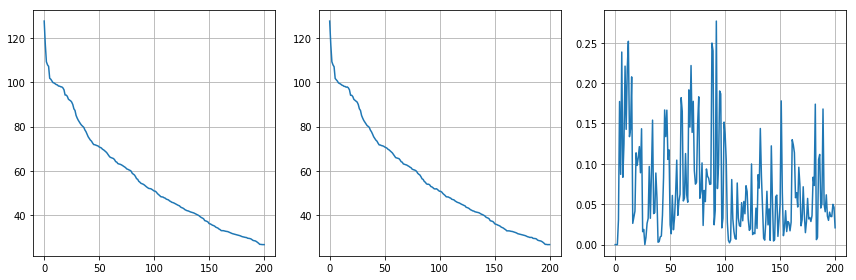

In [71]:
visualizeConvergence(report2)

In [67]:
res2.message

b'STOP: TOTAL NO. of ITERATIONS REACHED LIMIT'

In [72]:
res3, report3 = sheet_opt.optimize()

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 26.78975063509677
	Returning energy 26.78975063509677
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 0.9999999999999984
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.9999999999999984
	done with setVars
Energy eval called at dist: 8.775172493305243e-06
	done with setVars
	Evaluated energy 26.789691709919254
	Returning energy 26.789691709919254
Gradient eval called at dist: 8.775172493305243e-06
	done with setVars
Energy eval called at dist: 0.0012436578992014943
	done with setVars
	Evaluated energy 26.78146492112377
	Returning energy 26.78146492112377
Gradient eval called at dist: 0.0012436578992014943
	done with setVars
Energy eval called at dist: 0.5006218289496017
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.5006218289496017
	done with setVars
Energy eval 

In [73]:
res3.message

b'STOP: TOTAL NO. of ITERATIONS REACHED LIMIT'

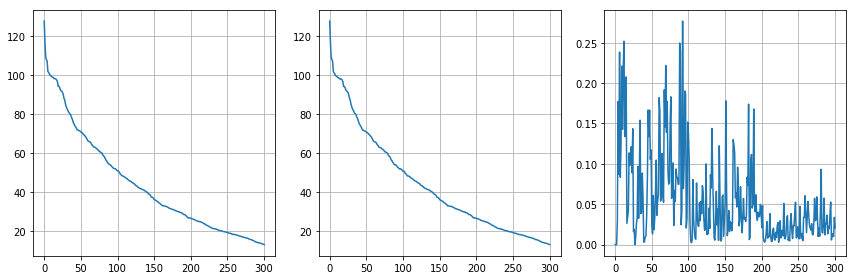

In [74]:
visualizeConvergence(report3)

In [75]:
res4, report4 = sheet_opt.optimize()

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 13.191580045580494
	Returning energy 13.191580045580494
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 1.0000000000000002
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 1.0000000000000002
	done with setVars
Energy eval called at dist: 7.942343834991423e-06
	done with setVars
	Evaluated energy 13.191531966281595
	Returning energy 13.191531966281595
Gradient eval called at dist: 7.942343834991423e-06
	done with setVars
Energy eval called at dist: 0.0015803536063373107
	done with setVars
	Evaluated energy 13.183747485158523
	Returning energy 13.183747485158523
Gradient eval called at dist: 0.0015803536063373107
	done with setVars
Committed design with energies:
 {'Full': 13.183747485158523, 'Fitting': 13.165899912494869, 'CollapseBarrier': 0.01784757266365517}
	gradient norm: 4.811885397696883
Energy eval called at dist: 0.0068

In [76]:
res5, report5 = sheet_opt.optimize()

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 10.485175745576152
	Returning energy 10.485175745576152
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 0.9999999999999996
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.9999999999999996
	done with setVars
Energy eval called at dist: 3.345291346382452e-06
	done with setVars
	Evaluated energy 10.48516722817805
	Returning energy 10.48516722817805
Gradient eval called at dist: 3.345291346382452e-06
	done with setVars
Energy eval called at dist: 0.03237924403468826
	done with setVars
	Evaluated energy 10.445814493845255
	Returning energy 10.445814493845255
Gradient eval called at dist: 0.03237924403468826
	done with setVars
Committed design with energies:
 {'Full': 10.445814493845255, 'Fitting': 10.444571907054998, 'CollapseBarrier': 0.0012425867902562259}
	gradient norm: 1.819534432382709
Energy eval called at dist: 0.02782154

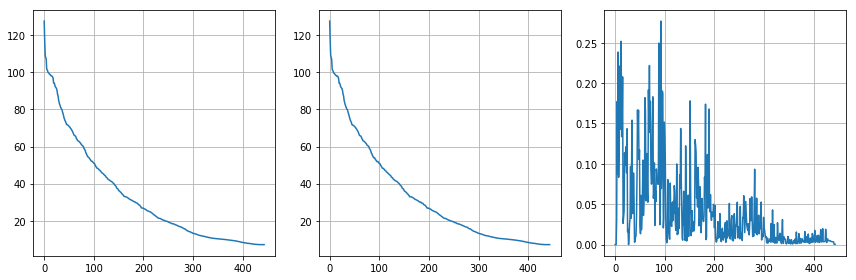

In [78]:
visualizeConvergence(report5)

We got stuck in a bad configuration where backtracking failed and so the objective of the commited design was under-estimated. Then the linesearch struggled to find a configuration whose accurately-computed objective was below the under-estimated objective.

We force the optimizer out of this configuration by making it accept a nearby iterate without a backtracking failure.

In [80]:
currDesignVars = sheet_opt.rso.getVars()
currEquilibrium = sheet_opt.rso.sheet().getVars()

In [82]:
sheet_opt.rso.energy()

7.1570391228572845

In [83]:
perturb = -sheet_opt.gradient(currDesignVars)

Gradient eval called at dist: 0.0
	done with setVars


In [85]:
sheet_opt.energy(currDesignVars + 0.01 * perturb)

Energy eval called at dist: 0.014515024373362375
	done with setVars
	Evaluated energy 7.182904443940198
	Returning energy 7.182904443940198


7.182904443940198

In [88]:
# Force the current design as a new point in the optimization
sheet_opt.opt_callback(None)

Committed design with energies:
 {'Full': 7.182904443940198, 'Fitting': 7.182798871342064, 'CollapseBarrier': 0.00010557259813389182}
	gradient norm: 2.7800493035536045


False

In [89]:
res6, report6 = sheet_opt.optimize()

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 7.182904443940198
	Returning energy 7.182904443940198
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 0.9999999999999993
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.9999999999999993
	done with setVars
Energy eval called at dist: 3.632613910012098e-06
	done with setVars
	Evaluated energy 7.18289434523892
	Returning energy 7.18289434523892
Gradient eval called at dist: 3.632613910012098e-06
	done with setVars
Energy eval called at dist: 0.00069144958403775
	done with setVars
	Evaluated energy 7.181013313288372
	Returning energy 7.181013313288372
Gradient eval called at dist: 0.00069144958403775
	done with setVars
Energy eval called at dist: 0.5003457247920184
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.5003457247920184
	done with setVars
Energy eval called a

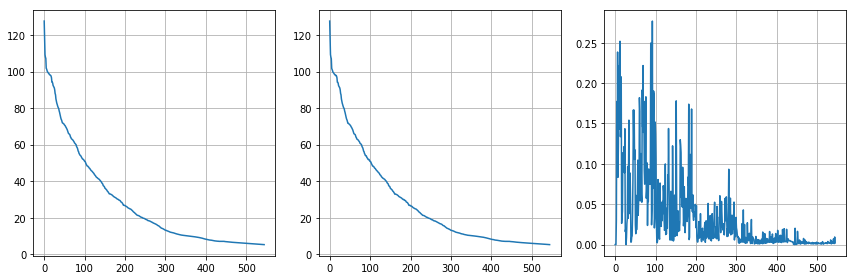

In [91]:
visualizeConvergence(report6)

In [90]:
res6.message

b'STOP: TOTAL NO. of ITERATIONS REACHED LIMIT'

In [92]:
res7, report7 = sheet_opt.optimize()

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 5.370734378134899
	Returning energy 5.370734378134899
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 0.9999999999999974
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.9999999999999974
	done with setVars
Energy eval called at dist: 2.526270433125823e-06
	done with setVars
	Evaluated energy 5.3707294936971826
	Returning energy 5.3707294936971826
Gradient eval called at dist: 2.526270433125823e-06
	done with setVars
Energy eval called at dist: 0.0004883573792533008
	done with setVars
	Evaluated energy 5.36980208959977
	Returning energy 5.36980208959977
Gradient eval called at dist: 0.0004883573792533008
	done with setVars
Energy eval called at dist: 0.5002441786896253
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.5002441786896253
	done with setVars
Energy eval ca

In [93]:
res7.message

b'STOP: TOTAL NO. of ITERATIONS REACHED LIMIT'

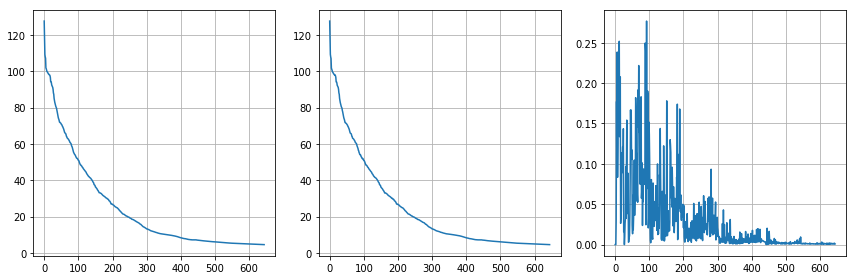

In [94]:
visualizeConvergence(report7)

In [95]:
res8, report8 = sheet_opt.optimize()

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 4.537731692897034
	Returning energy 4.537731692897034
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 0.9999999999999992
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.9999999999999992
	done with setVars
Energy eval called at dist: 1.9444451772872736e-06
	done with setVars
	Evaluated energy 4.537728799552117
	Returning energy 4.537728799552117
Gradient eval called at dist: 1.9444451772872736e-06
	done with setVars
Energy eval called at dist: 0.0004126436180412756
	done with setVars
	Evaluated energy 4.537131830787625
	Returning energy 4.537131830787625
Gradient eval called at dist: 0.0004126436180412756
	done with setVars
Energy eval called at dist: 0.5002063218090217
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.5002063218090217
	done with setVars
Energy eval 

KeyboardInterrupt: 

The current design puts us in a nearly unstable equilibrium. We manually perturb to the more stable (but worse) equilibrium configuration and restart the optimization from this point.

In [111]:
currDesignVars = sheet_opt.committedVars.copy()
currEquilibrium = sheet_opt.rso.sheet().getVars()

In [112]:
perturb = -sheet_opt.gradient(currDesignVars)

Gradient eval called at dist: 0.0
	done with setVars


In [114]:
sheet_opt.energy(currDesignVars + 0.002 * perturb)

Energy eval called at dist: 0.002188918030757167
	done with setVars
	Evaluated energy 4.526117148820948
	Returning energy 4.526117148820948


4.526117148820948

In [115]:
# Force the current design as a new point in the optimization
sheet_opt.opt_callback(None)

Committed design with energies:
 {'Full': 4.526117148820948, 'Fitting': 4.525538723961474, 'CollapseBarrier': 0.0005784248594738898}
	gradient norm: 3.499877718642288


False

In [116]:
res9, report9 = sheet_opt.optimize()

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 4.526117148820948
	Returning energy 4.526117148820948
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 0.9999999999999989
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.9999999999999989
	done with setVars
Energy eval called at dist: 4.572656690322815e-06
	done with setVars
	Evaluated energy 4.526101146359737
	Returning energy 4.526101146359737
Gradient eval called at dist: 4.572656690322815e-06
	done with setVars
Energy eval called at dist: 0.0003930928380953974
	done with setVars
	Evaluated energy 4.524756381749992
	Returning energy 4.524756381749992
Gradient eval called at dist: 0.0003930928380953974
	done with setVars
Energy eval called at dist: 0.5001965464190463
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.5001965464190463
	done with setVars
Energy eval ca

In [117]:
res9.message

b'STOP: TOTAL NO. of ITERATIONS REACHED LIMIT'

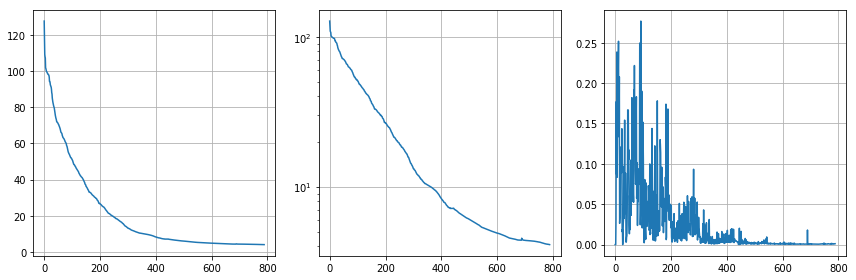

In [120]:
visualizeConvergence(report9)

In [121]:
res10, report10 = sheet_opt.optimize()

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 4.101985434533212
	Returning energy 4.101985434533212
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 0.9999999999999991
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.9999999999999991
	done with setVars
Energy eval called at dist: 1.7860224536053952e-06
	done with setVars
	Evaluated energy 4.101982987714603
	Returning energy 4.101982987714603
Gradient eval called at dist: 1.7860224536053952e-06
	done with setVars
Energy eval called at dist: 1.5460989389641156e-05
	done with setVars
	Evaluated energy 4.101964340565311
	Returning energy 4.101964340565311
Gradient eval called at dist: 1.5460989389641156e-05
	done with setVars
Energy eval called at dist: 0.5000077304946955
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.5000077304946955
	done with setVars
Energy eva

KeyboardInterrupt: 

The current design puts us in a nearly unstable equilibrium. We manually perturb to the more stable (but slightly worse) equilibrium configuration and restart the optimization from this point.

In [122]:
currDesignVars = sheet_opt.committedVars.copy()
currEquilibrium = sheet_opt.rso.sheet().getVars()

In [123]:
perturb = -sheet_opt.gradient(currDesignVars)

Gradient eval called at dist: 0.0
	done with setVars


In [126]:
sheet_opt.energy(currDesignVars + 0.008 * perturb)

Energy eval called at dist: 0.009354766033505135
	done with setVars
	Evaluated energy 4.052259349100659
	Returning energy 4.052259349100659


4.052259349100659

In [127]:
# Force the current design as a new point in the optimization
sheet_opt.opt_callback(None)

Committed design with energies:
 {'Full': 4.052259349100659, 'Fitting': 4.051680009440897, 'CollapseBarrier': 0.0005793396597613612}
	gradient norm: 1.7207573766444553


False

In [128]:
res11, report11 = sheet_opt.optimize()

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 4.052259349100659
	Returning energy 4.052259349100659
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 0.9999999999999996
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.9999999999999996
	done with setVars
Energy eval called at dist: 2.248268221681396e-06
	done with setVars
	Evaluated energy 4.052255481542563
	Returning energy 4.052255481542563
Gradient eval called at dist: 2.248268221681396e-06
	done with setVars
Energy eval called at dist: 4.492351634939208e-05
	done with setVars
	Evaluated energy 4.052182568780333
	Returning energy 4.052182568780333
Gradient eval called at dist: 4.492351634939208e-05
	done with setVars
Energy eval called at dist: 0.5000224617581758
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.5000224617581758
	done with setVars
Energy eval ca

KeyboardInterrupt: 

The current design puts us in a nearly unstable equilibrium. We manually perturb to the more stable (but slightly worse) equilibrium configuration and restart the optimization from this point.

In [129]:
currDesignVars = sheet_opt.committedVars.copy()
currEquilibrium = sheet_opt.rso.sheet().getVars()

In [130]:
perturb = -sheet_opt.gradient(currDesignVars)

Gradient eval called at dist: 0.0
	done with setVars


In [132]:
sheet_opt.energy(currDesignVars + 0.004 * perturb)

Energy eval called at dist: 0.00472876701787218
	done with setVars
	Evaluated energy 4.023391833705671
	Returning energy 4.023391833705671


4.023391833705671

In [133]:
# Force the current design as a new point in the optimization
sheet_opt.opt_callback(None)

Committed design with energies:
 {'Full': 4.023391833705671, 'Fitting': 4.022764461246492, 'CollapseBarrier': 0.0006273724591789019}
	gradient norm: 1.7688083088579423


False

In [134]:
res12, report12 = sheet_opt.optimize()

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 4.023391833705671
	Returning energy 4.023391833705671
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 0.9999999999999991
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.9999999999999991
	done with setVars
Energy eval called at dist: 2.3110681048267826e-06
	done with setVars
	Evaluated energy 4.023387747207898
	Returning energy 4.023387747207898
Gradient eval called at dist: 2.3110681048267826e-06
	done with setVars
Energy eval called at dist: 0.004438262387979484
	done with setVars
	Evaluated energy 4.021818175637156
	Returning energy 4.021818175637156
Gradient eval called at dist: 0.004438262387979484
	done with setVars
Energy eval called at dist: 0.002015205141827028
	done with setVars
	Evaluated energy 4.020426011311092
	Returning energy 4.020426011311092
Gradient eval called at dist: 0.002015205141827028
	done with setVa

In [135]:
res12.message

b'STOP: TOTAL NO. of ITERATIONS REACHED LIMIT'

In [151]:
import scipy

In [152]:
res14 = scipy.optimize.minimize(sheet_opt.energy, sheet_opt.rso.getVars(), jac=sheet_opt.gradient, method='L-BFGS-B', callback=sheet_opt.opt_callback, tol=0, options=dict(maxiter=5000, maxfev=20000, gtol=1e-16))
report14 = sheet_opt.report

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 3.899234480840724
	Returning energy 3.899234480840724
Gradient eval called at dist: 0.0
	done with setVars


/opt/local/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/ipykernel_launcher.py:1: OptimizeWarning: Unknown solver options: maxfev
  """Entry point for launching an IPython kernel.


Energy eval called at dist: 1.0000000000000009
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 1.0000000000000009
	done with setVars
Energy eval called at dist: 1.7459964338339217e-06
	done with setVars
	Evaluated energy 3.8992321484041845
	Returning energy 3.8992321484041845
Gradient eval called at dist: 1.7459964338339217e-06
	done with setVars
Energy eval called at dist: 0.00021526107762732962
	done with setVars
	Evaluated energy 3.8989589637809714
	Returning energy 3.8989589637809714
Gradient eval called at dist: 0.00021526107762732962
	done with setVars
Energy eval called at dist: 0.5001076305388125
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.5001076305388125
	done with setVars
Energy eval called at dist: 0.00021566245763044673
	done with setVars
	Evaluated energy 3.8989584704001876
	Returning energy 3.8989584704001876
Gradient eval called at dist: 0.000215

KeyboardInterrupt: 

In [163]:
currDesignVars = sheet_opt.committedVars.copy()
currEquilibrium = sheet_opt.rso.sheet().getVars()

In [164]:
perturb = -sheet_opt.gradient(currDesignVars)

Gradient eval called at dist: 0.0
	done with setVars


In [166]:
sheet_opt.energy(currDesignVars + 0.001 * perturb)

Energy eval called at dist: 0.0010439771160804402
	done with setVars
	Evaluated energy 3.88648851421995
	Returning energy 3.88648851421995


3.88648851421995

In [167]:
# Force the current design as a new point in the optimization
sheet_opt.opt_callback(None)

Committed design with energies:
 {'Full': 3.88648851421995, 'Fitting': 3.8861293923730478, 'CollapseBarrier': 0.0003591218469022168}
	gradient norm: 0.9275394328234412


False

In [168]:
res14 = scipy.optimize.minimize(sheet_opt.energy, sheet_opt.rso.getVars(), jac=sheet_opt.gradient, method='L-BFGS-B', callback=sheet_opt.opt_callback, tol=0, options=dict(maxiter=5000, gtol=1e-16))
report14 = sheet_opt.report

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 3.88648851421995
	Returning energy 3.88648851421995
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 0.9999999999999997
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.9999999999999997
	done with setVars
Energy eval called at dist: 1.211917937700631e-06
	done with setVars
	Evaluated energy 3.8864873903068826
	Returning energy 3.8864873903068826
Gradient eval called at dist: 1.211917937700631e-06
	done with setVars
Energy eval called at dist: 3.449184551944581e-05
	done with setVars
	Evaluated energy 3.886457531495117
	Returning energy 3.886457531495117
Gradient eval called at dist: 3.449184551944581e-05
	done with setVars
Energy eval called at dist: 0.5000172459227613
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.5000172459227613
	done with setVars
Energy eval ca

In [169]:
currDesignVars = sheet_opt.committedVars.copy()
currEquilibrium = sheet_opt.rso.sheet().getVars()

In [170]:
perturb = -sheet_opt.gradient(currDesignVars)

Gradient eval called at dist: 0.0
	done with setVars


In [185]:
sheet_opt.energy(currDesignVars + 0.001 * perturb)

Energy eval called at dist: 0.000942053357360865
	done with setVars
	Evaluated energy 3.955157326551887
	Returning energy 3.955157326551887


3.955157326551887

In [172]:
perturbedEquilibrium = sheet_opt.rso.sheet().getVars()

In [177]:
sheet_opt.energy(currDesignVars)

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 3.8419840021978455
	Returning energy 3.8419840021978455


3.8419840021978455

In [180]:
# Note that the perturbed design's equilibrium is actually a lower energy state for the current design.
print(targetAttractedSheet.energy())
targetAttractedSheet.setVars(perturbedEquilibrium)
print(targetAttractedSheet.energy())

In [186]:
# Force the current design as a new point in the optimization
sheet_opt.opt_callback(None)

Committed design with energies:
 {'Full': 3.955157326551887, 'Fitting': 3.954736446177151, 'CollapseBarrier': 0.00042088037473634357}
	gradient norm: 5.648843087346513


False

In [187]:
res15 = scipy.optimize.minimize(sheet_opt.energy, sheet_opt.rso.getVars(), jac=sheet_opt.gradient, method='L-BFGS-B', callback=sheet_opt.opt_callback, tol=0, options=dict(maxiter=5000, gtol=1e-16))
report15 = sheet_opt.report

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 3.955157326551887
	Returning energy 3.955157326551887
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 0.9999999999999968
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.9999999999999968
	done with setVars
Energy eval called at dist: 7.379289092074216e-06
	done with setVars
	Evaluated energy 3.9551156501945357
	Returning energy 3.9551156501945357
Gradient eval called at dist: 7.379289092074216e-06
	done with setVars
Energy eval called at dist: 0.0006596601626480839
	done with setVars
	Evaluated energy 3.9513873589573265
	Returning energy 3.9513873589573265
Gradient eval called at dist: 0.0006596601626480839
	done with setVars
Energy eval called at dist: 0.5003298300813227
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 0.5003298300813227
	done with setVars
Energy eva

KeyboardInterrupt: 

In [193]:
# Check if perturbed equilibrium is a lower energy state for the previous design (the design at the start of this last round of optimization)...
perturbedEquilibrium = sheet_opt.rso.sheet().getVars() 
prevDesignVars = currDesignVars.copy()
prevDesignEquilibrium = currEquilibrium.copy()

In [197]:
currDesignVars = sheet_opt.committedVars.copy()
currEquilibrium = sheet_opt.rso.sheet().getVars()

In [211]:
# Force the current design as a new point in the optimization
sheet_opt.opt_callback(None)

Committed design with energies:
 {'Full': 3.955139549212647, 'Fitting': 3.954679103911598, 'CollapseBarrier': 0.0004604453010488174}
	gradient norm: 5.584724231674893


False

In [212]:
res16 = scipy.optimize.minimize(sheet_opt.energy, sheet_opt.rso.getVars(), jac=sheet_opt.gradient, method='L-BFGS-B', callback=sheet_opt.opt_callback, tol=0, options=dict(maxiter=5000, gtol=1e-16))
report16 = sheet_opt.report

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 3.955139549212647
	Returning energy 3.955139549212647
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 1.000000000000001
	done with setVars
	Evaluated energy inf
	Returning energy 127566.95982780727
Gradient eval called at dist: 1.000000000000001
	done with setVars
Energy eval called at dist: 7.187734435590655e-06
	done with setVars
	Evaluated energy 3.9550994974644778
	Returning energy 3.9550994974644778
Gradient eval called at dist: 7.187734435590655e-06
	done with setVars
Energy eval called at dist: 0.016349717234421055
	done with setVars
	Evaluated energy 3.88504603307262
	Returning energy 3.88504603307262
Gradient eval called at dist: 0.016349717234421055
	done with setVars
Committed design with energies:
 {'Full': 3.88504603307262, 'Fitting': 3.882935288164965, 'CollapseBarrier': 0.0021107449076552985}
	gradient norm: 5.073864700827539
Energy eval called at dist: 0.062137200747782

In [213]:
res16.message

b'ABNORMAL_TERMINATION_IN_LNSRCH'

In [214]:
sheet_opt.rso.energy()

3.8324277385268184

In [216]:
currDesignVars = sheet_opt.committedVars.copy()
currEquilibrium = sheet_opt.rso.sheet().getVars()

In [394]:
np.savetxt('results/squidward/tf_optimization_fitting_weight_1e-2_designVars.txt', currDesignVars)
np.savetxt('results/squidward/tf_optimization_fitting_weight_1e-2_equilibrium.txt', currEquilibrium)

In [217]:
perturb = -sheet_opt.gradient(currDesignVars)

Gradient eval called at dist: 0.0
	done with setVars


In [218]:
sheet_opt.energy(currDesignVars + 1e-6 * perturb)

Energy eval called at dist: 9.503673680751368e-07
	done with setVars
	Evaluated energy 3.9615673741196837
	Returning energy 3.9615673741196837


3.9615673741196837

In [219]:
perturbedEquilibrium = sheet_opt.rso.sheet().getVars()

In [222]:
equilibriumJump = perturbedEquilibrium - currEquilibrium

In [ ]:
from tri_mesh_viewer import TriMeshViewer
eqjump_view = TriMeshViewer(isheet.visualizationMesh(), width=1024, height=640, vectorField=visualization.vectorFieldFromISheetVarField(isheet, equilibriumJump))
eqjump_view.show()

In [228]:
eqjump_view.getCameraParams()

((1.579330482103569, 1.0958499186671473, -0.6032513520004698),
 (0.6450795286208445, -0.020119953395618503, 0.7638505018848121),
 (0.9088554693961551, 0.8300133800247997, -0.04403055509454518))

In [ ]:
eqview2 = TriMeshViewer(visualization.EquilibriumMesh(targetAttractedSheet.sheet()), width=1024, height=640)
eqview2.show()

In [473]:
eqview2.setCameraParams(((-2.765818711099461, 0.8987941176083329, 0.19433344277398273),
 (0.09706369640916997, -0.05115148773896216, 0.993962858532185),
 (-0.4044358758261048, 0.10517014585763552, -0.07710486216183866)))

In [488]:
from utils import allEnergies

In [388]:
targetAttractedSheet.setVars(currEquilibrium)
eqview2.update()

In [381]:
sheet_opt.rso.energy(), targetAttractedSheet.energy()

(3.832427738527037, -374.8868802772137)

In [389]:
targetAttractedSheet.setVars(perturbedEquilibrium)
eqview2.update()

In [376]:
sheet_opt.rso.energy(), targetAttractedSheet.energy()

(3.9615674501534976, -374.8873921027414)

In [451]:
eqview2.update(preserveExisting=False, mesh=target_surface)

In [ ]:
# Decrease the forces pulling the sheet to the surface

In [422]:
targetAttractedSheet.fittingWeight = 1e-5

In [423]:
cr = inflation.inflation_newton(targetAttractedSheet, bdryVars, sheet_opt.opts)

In [452]:
eqview2.update(preserveExisting=True, mesh=visualization.EquilibriumMesh(targetAttractedSheet.sheet()))

In [426]:
sheet_opt_fit_1em5 = sheet_optimizer.PySheetOptimizer(targetAttractedSheet, bdryVars)

Committed design with energies:
 {'Full': 97.29240746045699, 'Fitting': 97.29240746045699, 'CollapseBarrier': 0.0}
	gradient norm: 872.5687665914227


Note: the instant collapse barrier `inf` return ensures that we quickly find a reasonable step size.

In [427]:
second_fitweight_res, second_fitweight_report = sheet_opt_fit_1em5.optimize()

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 97.29240746045699
	Returning energy 97.29240746045699
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 0.999999999999999
	done with setVars
	Evaluated energy inf
	Returning energy 97292.40746045699
Gradient eval called at dist: 0.999999999999999
	done with setVars
Energy eval called at dist: 0.0012910598608426242
	done with setVars
	Evaluated energy 96.20757610450397
	Returning energy 96.20757610450397
Gradient eval called at dist: 0.0012910598608426242
	done with setVars
Energy eval called at dist: 0.031247588816472376
	done with setVars
	Evaluated energy 204.52614806830726
	Returning energy 204.52614806830726
Gradient eval called at dist: 0.031247588816472376
	done with setVars
Energy eval called at dist: 0.002306621914865621
	done with setVars
	Evaluated energy 95.3724557925197
	Returning energy 95.3724557925197
Gradient eval called at dist: 0.002306621914865621
	done with setVars
En

KeyboardInterrupt: 

Force-accept the lower energy equilibrium...

In [429]:
sheet_opt_fit_1em5.opt_callback(None)

Committed design with energies:
 {'Full': 215.98155480404367, 'Fitting': 215.98155480404367, 'CollapseBarrier': 0.0}
	gradient norm: 1465.0152192867695


False

In [430]:
second_fitweight_res, second_fitweight_report = sheet_opt_fit_1em5.optimize()

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 215.98155480404367
	Returning energy 215.98155480404367
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 0.9999999999999988
	done with setVars
	Evaluated energy inf
	Returning energy 97292.40746045699
Gradient eval called at dist: 0.9999999999999988
	done with setVars
Energy eval called at dist: 0.0026624650485241787
	done with setVars
	Evaluated energy 212.06573654917148
	Returning energy 212.06573654917148
Gradient eval called at dist: 0.0026624650485241787
	done with setVars
Energy eval called at dist: 0.0053285771683154685
	done with setVars
	Evaluated energy 208.14753133833756
	Returning energy 208.14753133833756
Gradient eval called at dist: 0.0053285771683154685
	done with setVars
Energy eval called at dist: 0.5026642885841557
	done with setVars
	Evaluated energy inf
	Returning energy 97292.40746045699
Gradient eval called at dist: 0.5026642885841557
	done with setVars
Energy eva

In [ ]:
sheet_opt_fit_1em5.

In [480]:
np.savetxt('results/squidward/tf_optimization_fitting_weight_1e-5_designVars.txt', sheet_opt_fit_1em5.committedVars)
np.savetxt('results/squidward/tf_optimization_fitting_weight_1e-5_equilibrium.txt', sheet_opt_fit_1em5.rso.sheet().getVars())

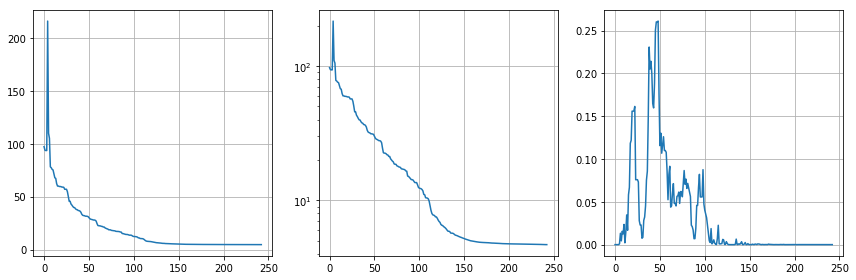

In [432]:
visualizeConvergence(second_fitweight_report)

In [444]:
targetAttractedSheet.fittingWeight = 0

In [445]:
cr = inflation.inflation_newton(targetAttractedSheet, bdryVars, sheet_opt.opts)

In [447]:
sheet_opt_nofit = sheet_optimizer.PySheetOptimizer(targetAttractedSheet, bdryVars)

Committed design with energies:
 {'Full': 5.302448590515667, 'Fitting': 5.302448590515667, 'CollapseBarrier': 0.0}
	gradient norm: 24.58746845570189


In [448]:
no_fitweight_res, no_fitweight_report = sheet_opt_nofit.optimize()

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 5.302448590515667
	Returning energy 5.302448590515667
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 0.9999999999999986
	done with setVars
	Evaluated energy inf
	Returning energy 5302.448590515667
Gradient eval called at dist: 0.9999999999999986
	done with setVars
Energy eval called at dist: 0.0007078136678749661
	done with setVars
	Evaluated energy 5.2852685126213945
	Returning energy 5.2852685126213945
Gradient eval called at dist: 0.0007078136678749661
	done with setVars
Energy eval called at dist: 0.03098542781015077
	done with setVars
	Evaluated energy 4.997926071229218
	Returning energy 4.997926071229218
Gradient eval called at dist: 0.03098542781015077
	done with setVars
Committed design with energies:
 {'Full': 4.997926071229218, 'Fitting': 4.997926071229218, 'CollapseBarrier': 0.0}
	gradient norm: 32.46934693612501
Energy eval called at dist: 0.01757857632930194
	done with se

In [456]:
# force ourselves out of an iterate whose equilibrium solve failed and underestimated the energy
sheet_opt_nofit.opt_callback(None)

Committed design with energies:
 {'Full': 4.671444437980223, 'Fitting': 4.671442311762027, 'CollapseBarrier': 2.126218196556382e-06}
	gradient norm: 8.665309943556142


False

In [457]:
no_fitweight_res_again, no_fitweight_report_again = sheet_opt_nofit.optimize()

Energy eval called at dist: 0.0
	done with setVars
	Evaluated energy 4.671444437980223
	Returning energy 4.671444437980223
Gradient eval called at dist: 0.0
	done with setVars
Energy eval called at dist: 0.9999999999999994
	done with setVars
	Evaluated energy inf
	Returning energy 5302.448590515667
Gradient eval called at dist: 0.9999999999999994
	done with setVars
Energy eval called at dist: 0.00025816495259922955
	done with setVars
	Evaluated energy 4.669509853976051
	Returning energy 4.669509853976051
Gradient eval called at dist: 0.00025816495259922955
	done with setVars
Committed design with energies:
 {'Full': 4.669509853976051, 'Fitting': 4.669509730829469, 'CollapseBarrier': 1.2314658302787126e-07}
	gradient norm: 7.15141924550457
Energy eval called at dist: 0.001605110878948212
	done with setVars
	Evaluated energy 4.662869249182128
	Returning energy 4.662869249182128
Gradient eval called at dist: 0.001605110878948212
	done with setVars
Committed design with energies:
 {'Full':

KeyboardInterrupt: 

In [481]:
np.savetxt('results/squidward/tf_optimization_no_fitting_weight_designVars.txt', sheet_opt_nofit.committedVars)
np.savetxt('results/squidward/tf_optimization_no_fitting_weight_equilibrium.txt', sheet_opt_nofit.rso.sheet().getVars())

In [467]:
isWallTri = iwv[s.triangles()].all(axis=1)

In [ ]:
designView = TriMeshViewer(targetAttractedSheet.mesh(), scalarField=isWallTri, width=1200, height=768)
designView.show()

In [471]:
designView.setCameraParams(((0.2321927358778552, -0.18983138617242915, 2.832657064231009),
 (0.0, 1.0, 0.0),
 (0.2321927358778552, -0.18983138617242915, 0.0)))

In [474]:
designMesh = targetAttractedSheet.mesh()

In [478]:
designMesh.save('opt_design.msh')